In [ ]:
import torch 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import os
from pathlib import Path

 

outdir_sim2 = Path(
    r"C:/Document/Serieux/Travail/Data_analysis_and_papers/benchmark_cebmf/cEBMF_sim_and_fit/tree"
) 
 
 
# Reproducibility
from cebmf_torch import cEBMF

[CGB] Epoch 10/10, Loss=4.4225, mu2=-0.080, sigma2=12.789
[CGB] Epoch 10/10, Loss=4.0665, mu2=-0.030, sigma2=8.925
[CGB] Epoch 10/10, Loss=3.5046, mu2=0.041, sigma2=5.027
[CGB] Epoch 10/10, Loss=3.3908, mu2=0.003, sigma2=4.492
[CGB] Epoch 10/10, Loss=1.8608, mu2=-0.019, sigma2=1.754
[CGB] Epoch 10/10, Loss=1.8492, mu2=0.020, sigma2=1.767
[CGB] Epoch 10/10, Loss=1.8278, mu2=-0.006, sigma2=1.871
[CGB] Epoch 10/10, Loss=4.4102, mu2=-0.160, sigma2=12.707
[CGB] Epoch 10/10, Loss=4.0598, mu2=-0.064, sigma2=8.922
[CGB] Epoch 10/10, Loss=3.4951, mu2=0.083, sigma2=5.022
[CGB] Epoch 10/10, Loss=3.3794, mu2=0.008, sigma2=4.489
[CGB] Epoch 10/10, Loss=1.7895, mu2=-0.035, sigma2=2.040
[CGB] Epoch 10/10, Loss=1.7723, mu2=0.055, sigma2=2.211
[CGB] Epoch 10/10, Loss=1.7596, mu2=-0.042, sigma2=2.246
[CGB] Epoch 10/10, Loss=4.4030, mu2=-0.240, sigma2=12.626
[CGB] Epoch 10/10, Loss=4.0593, mu2=-0.086, sigma2=8.921
[CGB] Epoch 10/10, Loss=3.4936, mu2=0.114, sigma2=5.021
[CGB] Epoch 10/10, Loss=3.3804, mu2

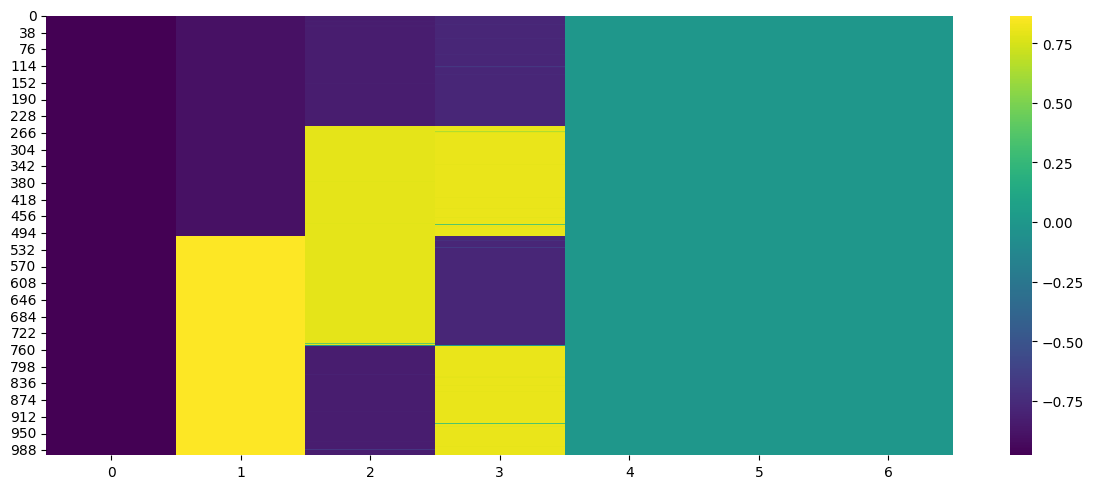

[CGB] Epoch 10/10, Loss=4.4651, mu2=-0.080, sigma2=13.256
[CGB] Epoch 10/10, Loss=4.0283, mu2=0.067, sigma2=8.599
[CGB] Epoch 10/10, Loss=3.3603, mu2=-0.008, sigma2=5.087
[CGB] Epoch 10/10, Loss=3.2389, mu2=0.055, sigma2=5.021
[CGB] Epoch 10/10, Loss=1.8479, mu2=-0.004, sigma2=1.930
[CGB] Epoch 10/10, Loss=1.8540, mu2=0.010, sigma2=1.715
[CGB] Epoch 10/10, Loss=1.8418, mu2=0.008, sigma2=1.730
[CGB] Epoch 10/10, Loss=4.4465, mu2=-0.160, sigma2=13.177
[CGB] Epoch 10/10, Loss=4.0227, mu2=0.136, sigma2=8.588
[CGB] Epoch 10/10, Loss=3.2780, mu2=-0.031, sigma2=5.364
[CGB] Epoch 10/10, Loss=3.0470, mu2=0.115, sigma2=5.320
[CGB] Epoch 10/10, Loss=1.7807, mu2=-0.016, sigma2=2.208
[CGB] Epoch 10/10, Loss=1.7695, mu2=0.016, sigma2=2.136
[CGB] Epoch 10/10, Loss=1.7679, mu2=0.034, sigma2=2.102
[CGB] Epoch 10/10, Loss=4.4405, mu2=-0.240, sigma2=13.105
[CGB] Epoch 10/10, Loss=4.0214, mu2=0.199, sigma2=8.586
[CGB] Epoch 10/10, Loss=3.0912, mu2=-0.067, sigma2=5.843
[CGB] Epoch 10/10, Loss=2.9565, mu2=0

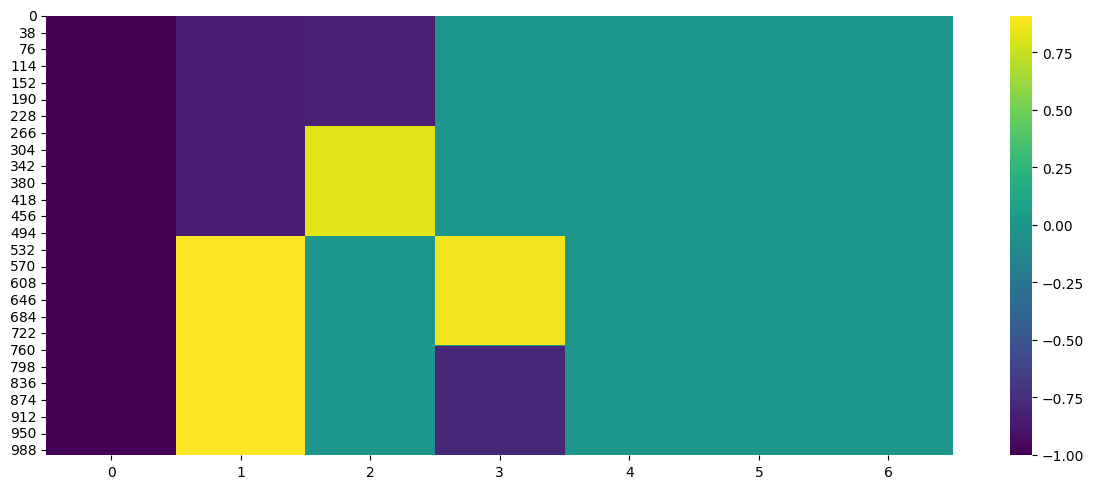

[CGB] Epoch 10/10, Loss=4.4194, mu2=0.080, sigma2=12.760
[CGB] Epoch 10/10, Loss=4.0719, mu2=-0.071, sigma2=8.906
[CGB] Epoch 10/10, Loss=2.7655, mu2=0.008, sigma2=7.317
[CGB] Epoch 10/10, Loss=2.6650, mu2=-0.013, sigma2=6.203
[CGB] Epoch 10/10, Loss=1.8618, mu2=-0.007, sigma2=1.813
[CGB] Epoch 10/10, Loss=1.8381, mu2=-0.006, sigma2=1.812
[CGB] Epoch 10/10, Loss=1.8412, mu2=-0.009, sigma2=1.784
[CGB] Epoch 10/10, Loss=4.4077, mu2=0.160, sigma2=12.677
[CGB] Epoch 10/10, Loss=4.0569, mu2=-0.139, sigma2=8.891


In [ ]:
#torch.manual_seed(1)

def reconstruction_rmse(L_est, F_est, X_true):
    """RMSE between reconstructed signal L_est @ F_est and the true noiseless signal."""
    X_hat = (L_est @ F_est).detach().cpu().numpy()
    X_true_np = X_true.detach().cpu().numpy()
    return np.sqrt(np.mean((X_hat - X_true_np) ** 2))

res_no_warm = list()
res_warm = list()

rmse_no_warm_cold = list()   # mycebmf2 (cgb_sharp_2, no warm start)
rmse_no_warm_warm = list()   # mycebmf21 (cgb_sharp_2, warm-started from mycebmf1)e
for  i in range (10):
    N = 2000  
    P= 200
# Scatter of x vs y 
    torch.manual_seed(i)

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------

    t0 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t1 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t2 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t11 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t12 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t21 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t22 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1

    a0 = t0 * torch.randn(P)
    b1 = t1 * torch.randn(P)
    b2 = t2 * torch.randn(P)
    detla11= t11 *torch.randn(P)

    detla12= t11 *torch.randn(P)
    detla21= t11 *torch.randn(P)
    detla22= t11 *torch.randn(P)  
    f_mat = torch.stack([a0,b1,b2, detla11, detla12,detla21, detla22 ], dim=0)
    
    N= 1000

    L = torch.zeros(N, 7, dtype=torch.float32)


    L[:,0]=1
    L[0:500, 1]=1

    L [500:,2]=1
    L[0:250,3]=1
    L[251:500,4]=1

    L[501:750,5]=1

    L[751:,6]=1
    X_true= L@f_mat 
    Z = L@f_mat +  torch.randn(N, P)    # (N, M)
    Z_np = Z.detach().cpu().numpy()
    mycebmf1 = cEBMF(data=Z, self_row_cov=True,
                      prior_L="cgb", K=7,
                      allow_backfitting=False,
                        prior_L_kwargs={"penalty": 1.15})
    mycebmf1.initialise_factors()
    mycebmf1.fit(10 ) # in pratice starting from not overly sparse prior help fit


    # --- warm start ---
    mycebmf21 = cEBMF(data=Z, self_row_cov=True,
                           prior_L="cgb_sharp_2", K=7,
                           allow_backfitting=False,
                            prior_L_kwargs={"penalty": 1.1 , 
                                            "omega":0.01 ,
                                            "n_layers":4})
    mycebmf21.initialise_factors( L=mycebmf1.L, F=mycebmf1.F)
    mycebmf21.fit(20)
 
    res_no_warm.append(mycebmf21.L)   # kept to match your original code
    res_warm.append(mycebmf21.L)
    rmse_no_warm_warm.append(torch.sqrt(  torch.mean( (X_true -mycebmf21.L@  mycebmf21.F.T)**2)))
 
    fit_cebmf_out=mycebmf21.L@  mycebmf21.F.T  
 
  
 
    np.savetxt(
     outdir_sim2 / f"L_cebmf_{i}.txt",
     mycebmf21.L,
     fmt="%.6f",
     delimiter="\t"
    )
 
    np.savetxt(
     outdir_sim2 / f"fit_cebmf_{i}.txt",
       fit_cebmf_out ,
     fmt="%.6f",
     delimiter="\t"
    )    
    print(i)
    print( rmse_no_warm_warm)
 
    fig, axes = plt.subplots(1, 1, figsize=(12, 5))
 
    sns.heatmap(
     res_warm[i],
     cmap="viridis",
     annot=False 
    ) 
 
  
    plt.tight_layout()
    plt.show()
      
rmse_no_warm_warm = torch.stack(rmse_no_warm_warm)
 

In [ ]:
mycebmf1.F

tensor([[-4.7662e-02, -6.9425e-02, -2.6244e-04,  ..., -9.9872e-02,
         -6.9926e-03,  1.7509e-02],
        [ 5.5221e-03, -1.8347e-02,  3.7974e-05,  ...,  5.0469e-03,
          1.7640e-01, -2.3005e-03],
        [ 3.7072e-02,  1.4825e-05,  5.6801e-02,  ...,  2.4572e-03,
         -5.5588e-03, -5.3343e-04],
        ...,
        [-1.5126e-03, -1.1808e-01, -1.0709e-01,  ..., -9.0319e-03,
         -2.2234e-04,  3.4904e-04],
        [-1.1941e-04,  1.1341e-04,  5.5442e-04,  ..., -1.2639e-03,
          2.0289e-03, -1.0343e-03],
        [-5.0337e-02,  4.9593e-02,  1.4832e-03,  ..., -1.0952e-02,
          1.1853e-01, -3.3171e-03]])

<Axes: >

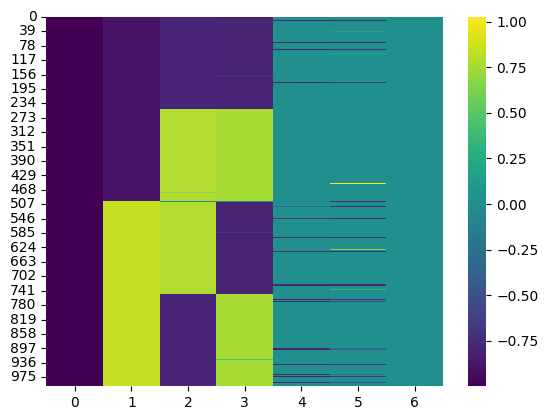

In [ ]:
sns.heatmap(
     res_warm[i],
     cmap="viridis",
     annot=False 
    )

In [ ]:
print(rmse_no_warm_warm)

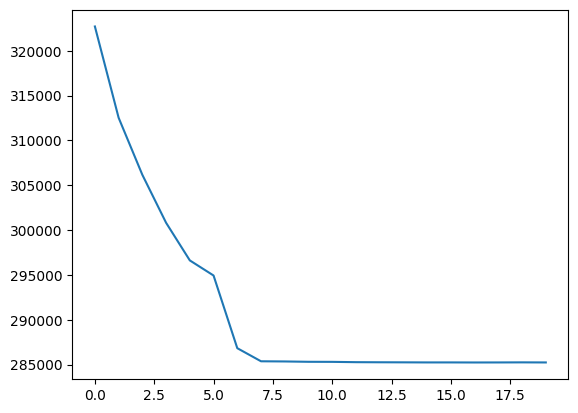

In [ ]:
plt.plot(mycebmf21.obj)